In [9]:
from dataclasses import dataclass
from typing import Union, Dict, Tuple, Optional, Literal
from PIL import Image
import io
from IPython.display import Image as IPythonImage

@dataclass
class TileSourceSize:
    """Configuration for the source size of a tile."""
    width: int
    height: int
    alignment: Literal["left", "center", "right"] = "center"

@dataclass
class TileConfig:
    """Configuration for a single tile in the grid."""
    content: Union[str, Tuple[int, int, int]]  # Either path to PNG or RGB color tuple
    is_image: bool = False  # True if content is a path to PNG, False if it's a color
    source_size: Optional[TileSourceSize] = None  # Required for images, ignored for colors

@dataclass
class GridConfig:
    """Configuration for the entire tiled grid."""
    canvas_size: int  # Width/height of the square canvas
    tile_size: int    # Width/height of each square tile (canvas_size / 2)

def process_image_for_tile(image: Image.Image, source_size: TileSourceSize) -> Image.Image:
    """Process an image maintaining aspect ratio and handling alignment.
    
    Args:
        image: Original PIL Image
        source_size: Configuration for target size and alignment
        
    Returns:
        PIL Image resized and positioned according to configuration
    """
    # Get original aspect ratio
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height
    
    # Calculate new dimensions based on target height
    new_height = source_size.height
    new_width = int(new_height * aspect_ratio)
    
    # Resize image maintaining aspect ratio
    resized_img = image.resize((new_width, new_height))
    
    # Create canvas of target source size
    canvas = Image.new('RGB', (source_size.width, source_size.height), (255, 255, 255))
    
    # Calculate paste position based on alignment
    if source_size.alignment == "left":
        x_pos = 0
    elif source_size.alignment == "right":
        x_pos = source_size.width - new_width
    else:  # center
        x_pos = (source_size.width - new_width) // 2
        
    # Paste resized image onto canvas
    canvas.paste(resized_img, (x_pos, 0))
    return canvas

def create_tiled_image(config: GridConfig, tiles: Dict[int, TileConfig]) -> bytes:
    """Create a tiled image based on configuration."""
    # Create base image
    img = Image.new('RGB', (config.canvas_size, config.canvas_size), (255, 255, 255))
    
    # Define tile positions
    tile_positions = {
        0: (0, 0),                    # top-left
        1: (config.tile_size, 0),     # top-right
        2: (0, config.tile_size),     # bottom-left
        3: (config.tile_size, config.tile_size)  # bottom-right
    }
    
    # Process each tile
    for idx, tile_config in tiles.items():
        if idx not in range(4):
            raise ValueError(f"Invalid tile index: {idx}. Must be 0-3.")
            
        x, y = tile_positions[idx]
        
        if tile_config.is_image:
            if not tile_config.source_size:
                raise ValueError(f"Source size must be specified for image tile at index {idx}")
                
            # Load and process PNG
            with Image.open(tile_config.content) as tile_img:
                # Process image to source size with alignment
                processed_img = process_image_for_tile(tile_img, tile_config.source_size)
                # Resize to final tile size
                processed_img = processed_img.resize((config.tile_size, config.tile_size))
                img.paste(processed_img, (x, y))
        else:
            # Fill with color
            color_tile = Image.new('RGB', (config.tile_size, config.tile_size), tile_config.content)
            img.paste(color_tile, (x, y))
    
    # Convert to bytes
    output = io.BytesIO()
    img.save(output, format='PNG')
    output.seek(0)
    return output.getvalue()

In [12]:
# Configuration
grid_config = GridConfig(
    canvas_size=1050,  # 1050x1050 canvas
    tile_size=525      # 525x525 tiles (canvas_size / 2)
)

# Tile configurations
tiles = {
    0: TileConfig(
        content="chart.png",
        is_image=True,
        source_size=TileSourceSize(
            width=671,
            height=261,
            alignment="center"
        )
    ),
    1: TileConfig((255, 0, 0), is_image=False),  # Red color
    2: TileConfig((0, 255, 0), is_image=False),  # Green color
    3: TileConfig(
        content="test.png",
        is_image=True,
        source_size=TileSourceSize(
            width=671,
            height=261,
            alignment="left"
        )
    )
}

# Create the tiled image
image_data = create_tiled_image(grid_config, tiles)

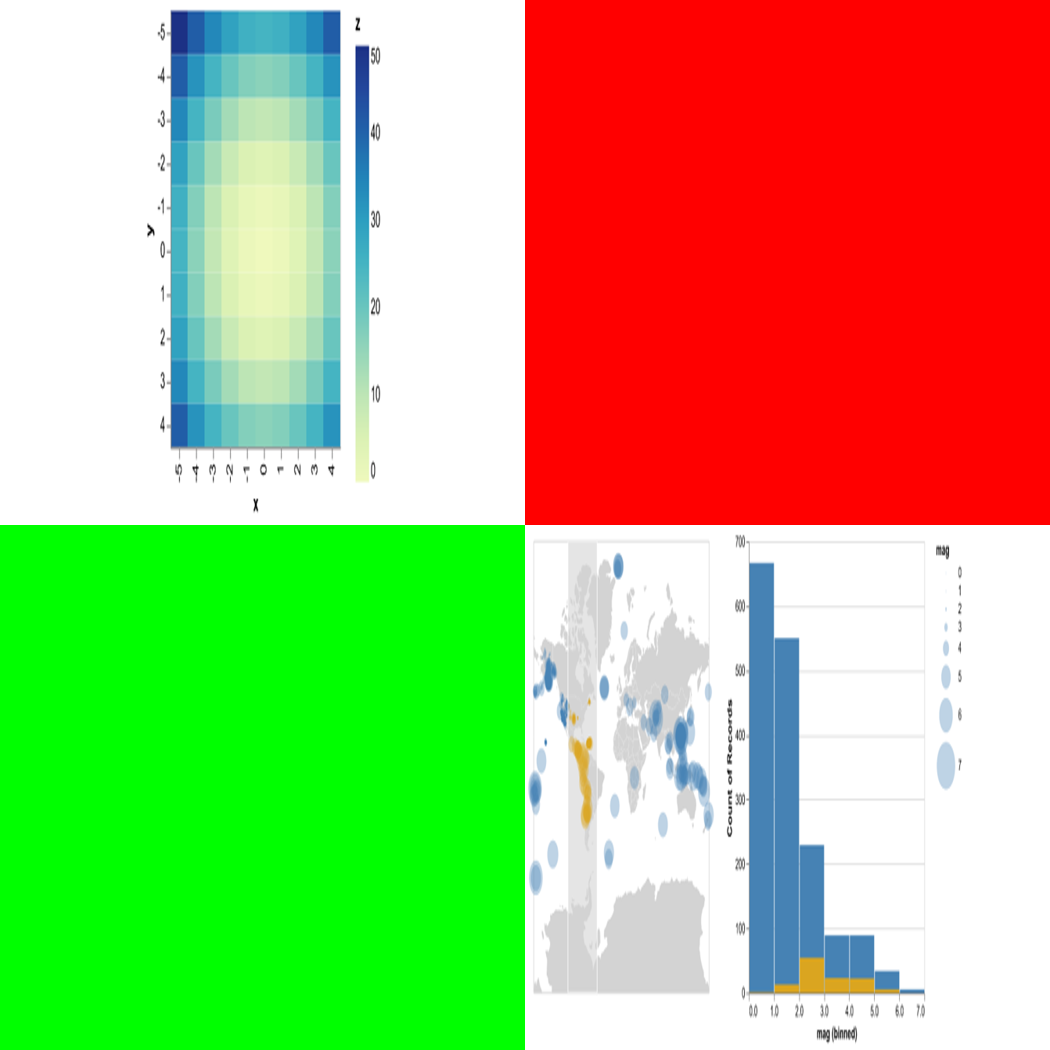

In [13]:
IPythonImage(image_data)